In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys
import torch

PROJECT_ROOT = "/content/drive/MyDrive/Explainable Detection of Online Sexism"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
os.environ["EDOS_CONFIG"] = "/content/drive/MyDrive/Explainable Detection of Online Sexism/config/config_v4.yaml"

from src.pipeline import setup, run_rnn_binary, run_rnn_category, run_transformer_binary, run_transformer_category
from config.config import (
    DATA_PATH, GLOVE_PATH, EMBED_DIM, MAX_VOCAB, MAX_LEN, HIDDEN_DIM, BATCH_SIZE, BATCH_SIZE_TRANSFORMER,
    MODEL_NAME, TRANSFORMER_MAX_LEN, EPOCHS, PATIENCE, USE_FOCAL, FOCAL_GAMMA, BINARY_LABELS, CATEGORY_LABELS,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
state = setup(device)

print(f"Data        : {DATA_PATH}")
print(f"GloVe       : {GLOVE_PATH}")
print(f"Embed dim   : {EMBED_DIM}")
print(f"Transformer : {MODEL_NAME}")
print(f"Epochs      : {EPOCHS}  |  Patience: {PATIENCE}")
print(f"Use Focal   : {USE_FOCAL}  |  gamma: {FOCAL_GAMMA}")

Mounted at /content/drive
Device: cuda
Loading data ...
Binary   — train: 16000  test: 4000
Category — train: 3884  test: 970

Building vocab + loading GloVe ...
Vocabulary size: 20000
GloVe coverage: 17294 / 20000 ( 86.5%)

Building RNN loaders ...
Building Transformer loaders ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Binary weights  : tensor([0.6603, 2.0597], device='cuda:0')
Category weights: tensor([2.7429, 0.5344, 0.7290, 2.5486], device='cuda:0')
Data        : /content/drive/MyDrive/Explainable Detection of Online Sexism/Dataset/edos_clean.csv
GloVe       : /content/drive/MyDrive/Explainable Detection of Online Sexism/GloVe/glove.twitter.27B.200d.txt
Embed dim   : 200
Transformer : roberta-base
Epochs      : 30  |  Patience: 6
Use Focal   : False  |  gamma: 2.0



BiLSTM — Task A (Binary)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.5900     0.7219    0.6815    0.7728    0.7353    LR: 1.00e-03


2      0.5289     0.8005    0.7594    0.8485    0.7882    LR: 1.00e-03


3      0.4943     0.8325    0.7958    0.8380    0.7854    LR: 1.00e-03


4      0.4477     0.8734    0.8424    0.8065    0.7608    LR: 1.00e-03


5      0.3974     0.9162    0.8926    0.7887    0.7434    LR: 5.00e-04


6      0.3337     0.9623    0.9502    0.8297    0.7677    LR: 5.00e-04


7      0.3078     0.9805    0.9738    0.8385    0.7690    LR: 5.00e-04


8      0.2994     0.9860    0.9811    0.8123    0.7570    LR: 2.50e-04

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.90      0.85      0.87      3030
      Sexist       0.60      0.69      0.64       970

    accuracy                           0.81      4000
   macro avg       0.75      0.77      0.76      4000
weighted avg       0.82      0.81      0.82      4000

Accuracy : 0.8123
Macro F1 : 0.7570
Weighted F1 : 0.8167

Confusion Matrix (raw):
[[2578  452]
 [ 299  671]]


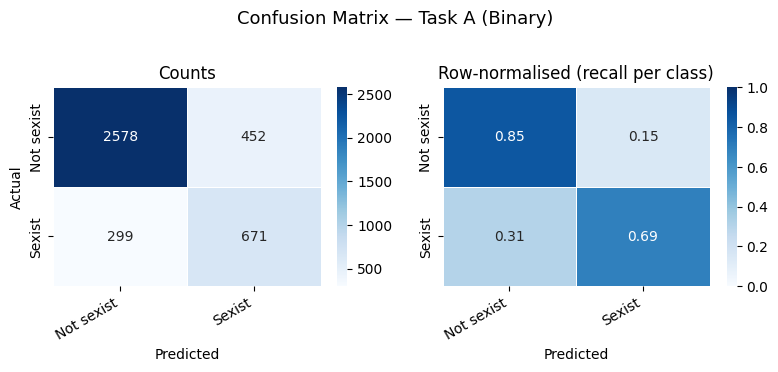

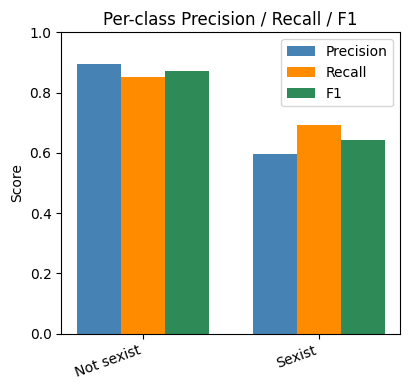


ERROR ANALYSIS

Total errors: 751 / 4000 (18.8%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,299,970,30.8
0,Not sexist,452,3030,14.9



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,452
1,Sexist,Not sexist,299


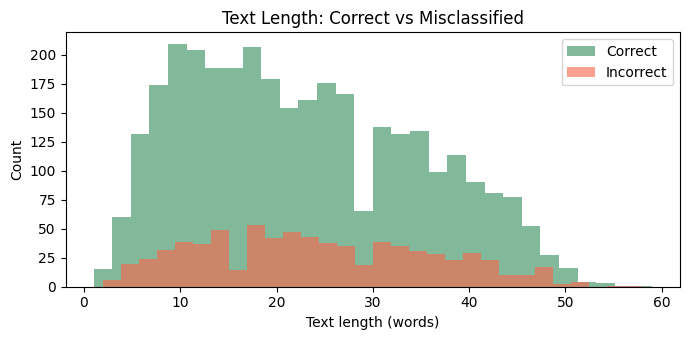


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 452)
    • (0.80) i have some unwashed underwear she can sniff i am not sure if it is sarin but i am positive it is toxic and probably wmd
    • (0.77) yes he can only top men fuck non ugly women nowadays
    • (0.82) you mean those videos where a woman slaps a guy when she's fucked up? we see those everyday already.

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 299)
    • (0.84) well then good because someone has to knock her ass back in line when she acts like a woman and posts bullshit about her
    • (0.83) i would pay to see her ass cracker. #nsfw
    • (0.83) if you don't want your mother fucked, keep her off the streets

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [2]:
rnn_binary = run_rnn_binary(state, device)


BiLSTM — Task B (Category)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.3745     0.2786    0.2826    0.4000    0.3950    LR: 1.00e-03


2      1.1886     0.4547    0.4605    0.3258    0.3394    LR: 1.00e-03


3      1.0944     0.5134    0.5313    0.4979    0.4939    LR: 1.00e-03


4      0.9912     0.6004    0.6335    0.4567    0.4439    LR: 1.00e-03


5      0.9073     0.6720    0.7124    0.4784    0.4529    LR: 1.00e-03


6      0.8296     0.7436    0.7874    0.5082    0.4651    LR: 5.00e-04


7      0.7224     0.8437    0.8779    0.5010    0.4585    LR: 5.00e-04


8      0.6635     0.8903    0.9180    0.5278    0.4734    LR: 5.00e-04


9      0.6287     0.9230    0.9384    0.5289    0.4820    LR: 2.50e-04

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.49      0.47      0.48        89
           Derogation       0.57      0.62      0.59       454
            Animosity       0.50      0.48      0.49       333
Prejudiced Discussion       0.42      0.32      0.36        94

             accuracy                           0.53       970
            macro avg       0.50      0.47      0.48       970
         weighted avg       0.52      0.53      0.53       970

Accuracy : 0.5289
Macro F1 : 0.4820
Weighted F1 : 0.5252

Confusion Matrix (raw):
[[ 42  27  15   5]
 [ 19 281 133  21]
 [ 12 145 160  16]
 [ 12  43   9  30]]


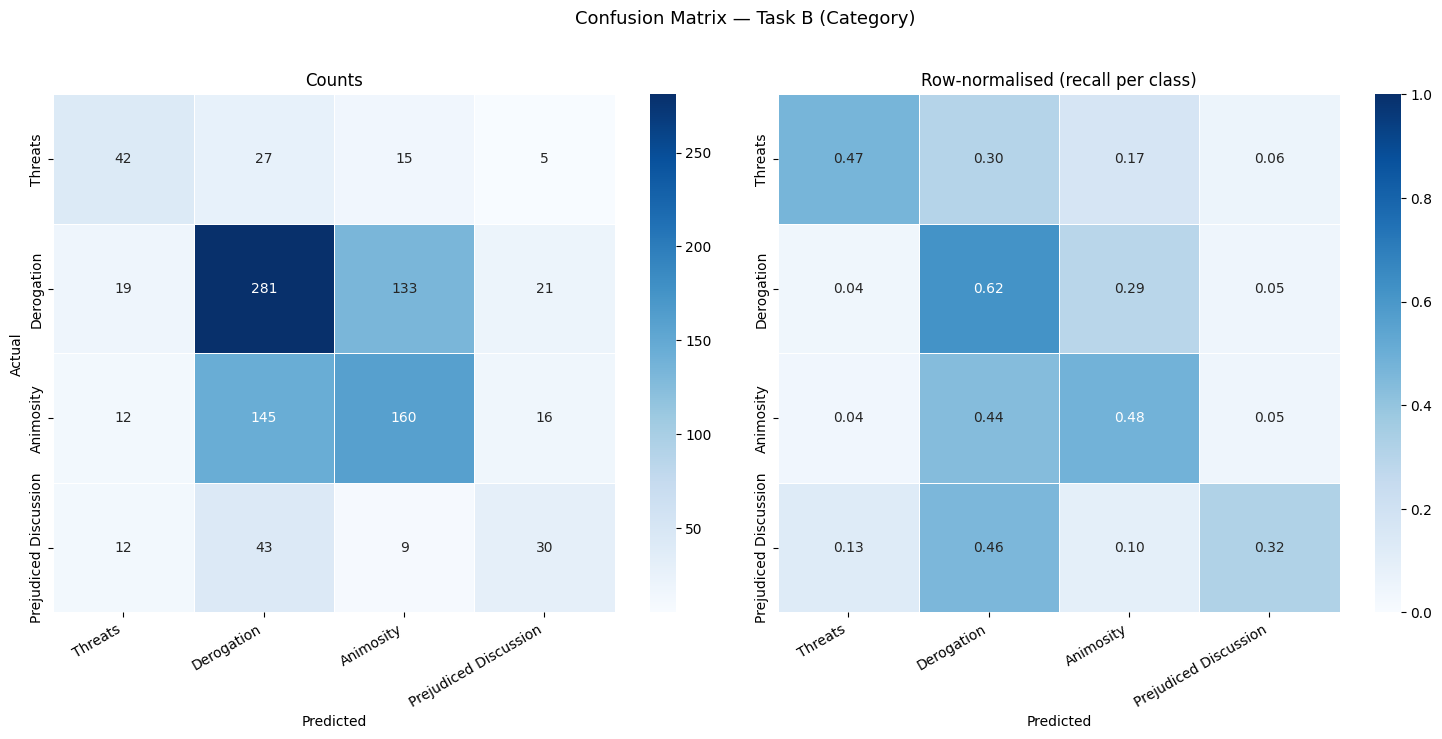

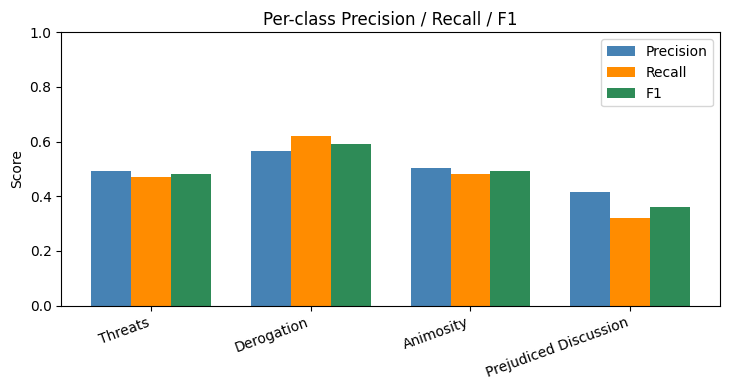


ERROR ANALYSIS

Total errors: 457 / 970 (47.1%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,64,94,68.1
0,Threats,47,89,52.8
2,Animosity,173,333,52.0
1,Derogation,173,454,38.1



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Animosity,Derogation,145
3,Derogation,Animosity,133
7,Prejudiced Discussion,Derogation,43
10,Threats,Derogation,27
4,Derogation,Prejudiced Discussion,21
5,Derogation,Threats,19
1,Animosity,Prejudiced Discussion,16
9,Threats,Animosity,15
2,Animosity,Threats,12
8,Prejudiced Discussion,Threats,12


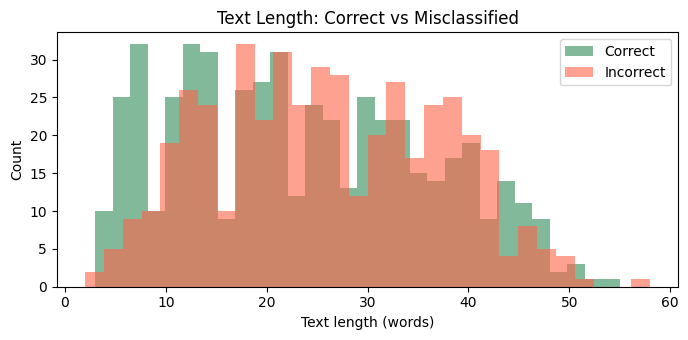


Sample misclassified examples:

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 145)
    • (0.45) lol that fat girl . black men cant catch up to us so they are angry . soo black men are angry because they are not marry
    • (0.36) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (0.73) most here would fuck her.

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 133)
    • (0.47) well then good because someone has to knock her ass back in line when she acts like a woman and posts bullshit about her
    • (0.62) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.82) she didn't have to be a bitch about it. she literally went out of her way to rub the rejection in his face, when a simpl

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 43)
    • (0.78) yes, it is new. what remains constant is th

In [3]:
rnn_category = run_rnn_category(state, device)


roberta-base — Task A (Binary)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


...

11     0.3163     0.9822    0.9758    0.8790    0.8262    LR: 7.92e-06


12     0.3093     0.9855    0.9803    0.8383    0.7994    LR: 7.50e-06


13     0.2996     0.9883    0.9841    0.8810    0.8283    LR: 7.08e-06


14     0.2991     0.9896    0.9859    0.8670    0.8207    LR: 6.67e-06


15     0.2940     0.9916    0.9886    0.8662    0.8212    LR: 6.25e-06

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.92      0.90      0.91      3030
      Sexist       0.71      0.75      0.73       970

    accuracy                           0.87      4000
   macro avg       0.82      0.83      0.82      4000
weighted avg       0.87      0.87      0.87      4000

Accuracy : 0.8662
Macro F1 : 0.8212
Weighted F1 : 0.8674

Confusion Matrix (raw):
[[2736  294]
 [ 241  729]]


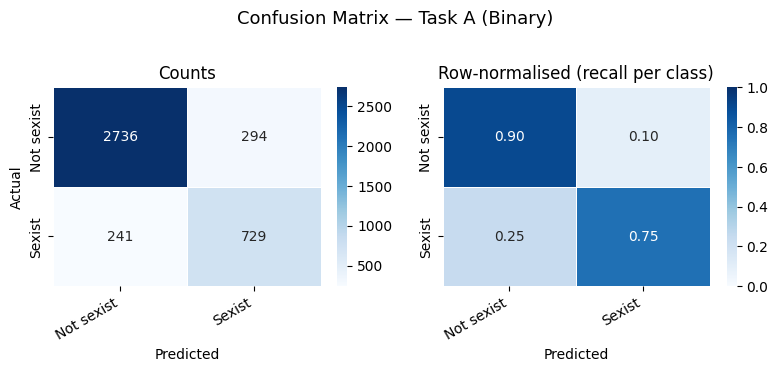

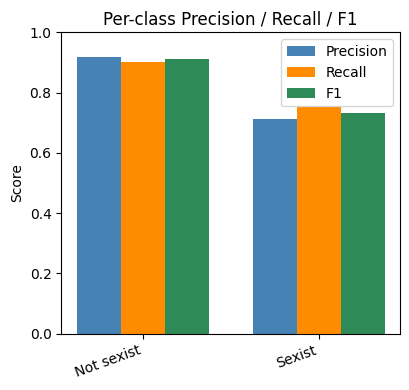


ERROR ANALYSIS

Total errors: 535 / 4000 (13.4%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,241,970,24.8
0,Not sexist,294,3030,9.7



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,294
1,Sexist,Not sexist,241


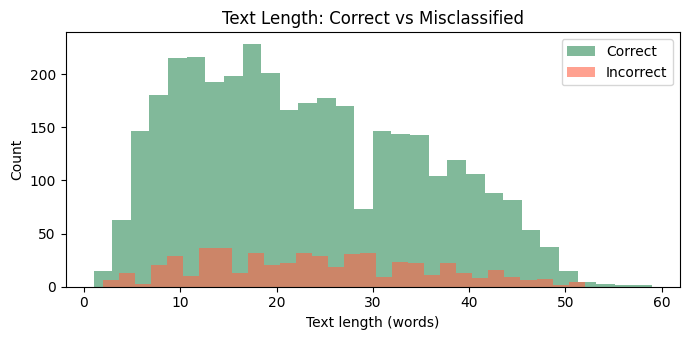


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 294)
    • (0.98) most men know instinctually the game. but their ego's are so fucking big that they think, not mine, not me. bang bang sh
    • (0.99) little girls in globalist “refugee” camps are bought and sold by men pretending to be their fathers, who rape them and u
    • (0.97) welcome to gender equality. suck it!

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 241)
    • (0.87) i would pay to see her ass cracker. #nsfw
    • (0.87) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (0.87) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [4]:
tf_binary = run_transformer_binary(state, device)


roberta-base — Task B (Category)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.4872     0.3404    0.2088    0.2814    0.1760    LR: 1.67e-06


...

15     0.5571     0.9809    0.9849    0.6093    0.6087    LR: 6.25e-06


16     0.5522     0.9830    0.9865    0.6134    0.6057    LR: 5.83e-06


17     0.5462     0.9884    0.9899    0.6227    0.6114    LR: 5.42e-06


18     0.5439     0.9900    0.9897    0.6103    0.6021    LR: 5.00e-06


19     0.5395     0.9912    0.9932    0.6062    0.6006    LR: 4.58e-06

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.70      0.61      0.65        89
           Derogation       0.63      0.66      0.64       454
            Animosity       0.56      0.56      0.56       333
Prejudiced Discussion       0.58      0.52      0.55        94

             accuracy                           0.61       970
            macro avg       0.62      0.59      0.60       970
         weighted avg       0.61      0.61      0.61       970

Accuracy : 0.6062
Macro F1 : 0.6006
Weighted F1 : 0.6058

Confusion Matrix (raw):
[[ 54  17  15   3]
 [ 12 299 121  22]
 [  6 131 186  10]
 [  5  27  13  49]]


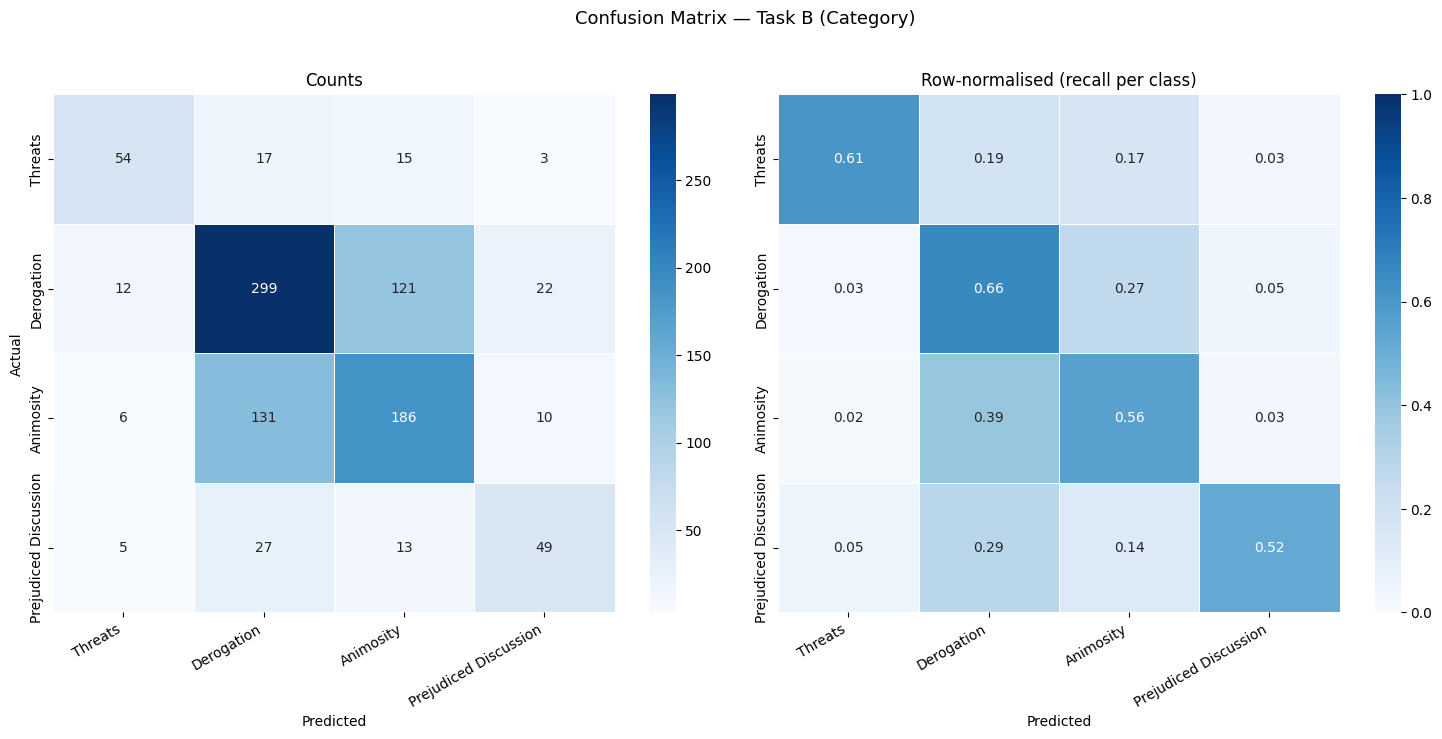

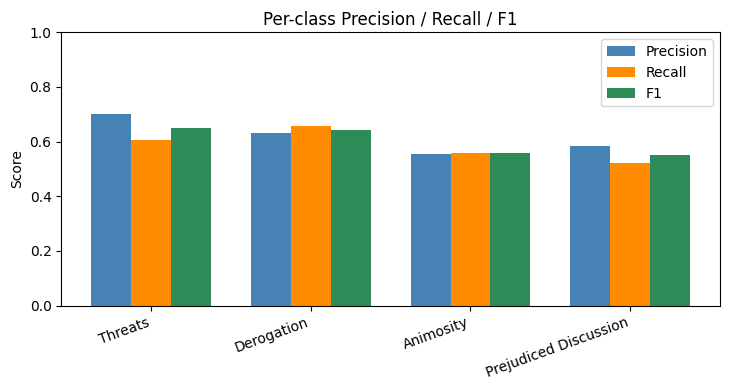


ERROR ANALYSIS

Total errors: 382 / 970 (39.4%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,45,94,47.9
2,Animosity,147,333,44.1
0,Threats,35,89,39.3
1,Derogation,155,454,34.1



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Animosity,Derogation,131
3,Derogation,Animosity,121
7,Prejudiced Discussion,Derogation,27
4,Derogation,Prejudiced Discussion,22
10,Threats,Derogation,17
9,Threats,Animosity,15
6,Prejudiced Discussion,Animosity,13
5,Derogation,Threats,12
1,Animosity,Prejudiced Discussion,10
2,Animosity,Threats,6


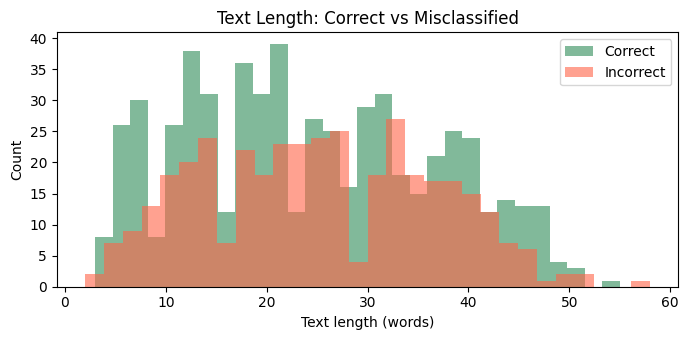


Sample misclassified examples:

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 131)
    • (0.79) most here would fuck her.
    • (0.79) soy boys pms worse than women cause it's 24/7. they get their delicate feelings hurt because of lack of testosterone.it'
    • (0.71) lol being an ugly dyke and an annoying jew are plenty enough reason to find her unwatchable.

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 121)
    • (0.86) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.74) i bet her future husband won't have anywhere near that much sex during his marriage lifetime with her.
    • (0.84) the view. empty head emotional woman's daily bitchcraft lesson.

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 27)
    • (0.79) yes, it is new. what remains constant is that feminists are playing to the fears of women to instill hate.
    • (0.79) oh man i'm so sorry. yep t

In [5]:
tf_category = run_transformer_category(state, device)